In [1]:
import sys
import os
import numpy as np
import torch
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split
from scipy.stats import pearsonr

In [2]:
project_root = os.path.abspath("..")
if project_root not in sys.path:
    sys.path.insert(0, project_root)

In [3]:
from kszcnn.same_real_cnn_density_group_M import *

In [4]:
print("SET:", set_name)
print("GRID_FILE:", GRID_FILE)
print("HALO_FILE:", HALO_FILE)
print("REAL_IDX:", REAL_IDX)

SET: 1P_0
GRID_FILE: /home/sucharita/kszCNN/data/Grids_Mcdm_IllustrisTNG_1P_128_z=0.0.npy
HALO_FILE: /home/sucharita/kszCNN/data/groups_090_1P_0.hdf5
REAL_IDX: 0


In [5]:
np.random.seed(SEED)
torch.manual_seed(SEED)

In [6]:
#  1. Load grids
grid = memmap_grid_slices(GRID_FILE, [REAL_IDX])[0]

print("Grid shapes:", grid.shape)

Grid shapes: (128, 128, 128)


In [7]:
# 2. Smooth density
delta = smooth_density_kspace(grid, SMOOTH_SCALE)

In [8]:
#  3. Normalize
mean = delta.mean()
std  = delta.std() + 1e-12

delta = (delta - mean) / std

In [9]:
# 4. Load halos
pos, vel, mass = load_halos(HALO_FILE)
feature = load_feature_file(HALO_FILE, feature_type="group_M")
'''
feature_dict = load_feature_file(HALO_FILE)
feature = feature_dict["mass_fof"]  
feature = np.array(feature) 
'''

'\nfeature_dict = load_feature_file(HALO_FILE)\nfeature = feature_dict["mass_fof"]  \nfeature = np.array(feature) \n'

In [10]:
rng1 = np.random.RandomState(SEED)
rng2 = np.random.RandomState(SEED + 1)


In [11]:
full_ds_clean = HaloDataset(
    delta, pos, vel,
    mass,
    feature,
    feature_type="group_M",   # or "nsubs"
    mass_cut=MASS_CUT,
    rng=rng1
)


Selected halos: 547


In [12]:
idxs = np.arange(len(full_ds_clean))

train_idx, test_idx = train_test_split(
    idxs, test_size=0.2, random_state=SEED
)

train_idx, val_idx = train_test_split(
    train_idx, test_size=0.2, random_state=SEED)

In [13]:
#mask = mass > MASS_CUT
#filtered_feature = feature[mask]

In [14]:
'''
train_feat = train_feat = filtered_feature[train_idx]

log_feat = np.log10(train_feat + 1e-6)
feat_mean = log_feat.mean()
feat_std = log_feat.std()
'''

'\ntrain_feat = train_feat = filtered_feature[train_idx]\n\nlog_feat = np.log10(train_feat + 1e-6)\nfeat_mean = log_feat.mean()\nfeat_std = log_feat.std()\n'

In [15]:
pos_all = pos.copy()

pos_all[test_idx] = redshift_err(
    pos_all[test_idx], sigma_z=1e-4)

In [17]:
full_ds = HaloDataset(
    delta, pos_all, vel, mass,
    feature,
    feature_type="group_M", 
    mass_cut=MASS_CUT,
    rng=rng2
)


Selected halos: 547


In [18]:
train_ds = Subset(full_ds, train_idx)
val_ds   = Subset(full_ds, val_idx)
test_ds  = Subset(full_ds, test_idx)

In [19]:
tr_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH)
te_loader  = DataLoader(test_ds, batch_size=BATCH)

In [20]:
#  9. Normalize velocity
y_train = np.array([full_ds[i][1] for i in train_idx])

y_mean = y_train.mean()
y_std  = y_train.std() + 1e-12

print("Velocity mean/std:", y_mean, y_std)

Velocity mean/std: 0.36430642 107.621216


In [21]:
#  6. Linear baseline 
vlin_grid = compute_vlin_from_density(
    grid, R_smooth=SMOOTH_SCALE
    )

test_pos = np.array([full_ds.pos[i] for i in test_idx])
true_vz  = full_ds.vz[test_idx]
vlin_baseline = vlin_at_halos(vlin_grid, test_pos)
rho_vlin = np.corrcoef(true_vz, vlin_baseline)[0,1]


print("Linear theory correlation:", rho_vlin)

Linear theory correlation: 0.8811998544715238


In [22]:
model = CNN().to(DEVICE)

In [23]:
train_model(
        model, tr_loader, val_loader, y_mean, y_std
    )

Epoch 1: Train=4.931e-01 | Val=6.109e-01
Epoch 2: Train=3.873e-01 | Val=5.167e-01
Epoch 3: Train=3.182e-01 | Val=3.411e-01
Epoch 4: Train=2.792e-01 | Val=3.656e-01
Epoch 5: Train=2.575e-01 | Val=3.181e-01
Epoch 6: Train=2.608e-01 | Val=3.317e-01
Epoch 7: Train=2.343e-01 | Val=3.231e-01
Epoch 8: Train=2.289e-01 | Val=3.216e-01
Epoch 9: Train=2.262e-01 | Val=3.837e-01
Epoch 10: Train=2.422e-01 | Val=3.373e-01
Epoch 11: Train=2.210e-01 | Val=3.287e-01
Epoch 12: Train=2.289e-01 | Val=3.352e-01
Epoch 13: Train=2.165e-01 | Val=3.620e-01
Epoch 14: Train=2.102e-01 | Val=3.260e-01
Epoch 15: Train=2.034e-01 | Val=3.248e-01
Epoch 16: Train=2.051e-01 | Val=3.149e-01
Epoch 17: Train=2.200e-01 | Val=3.081e-01
Epoch 18: Train=1.970e-01 | Val=3.266e-01
Epoch 19: Train=1.925e-01 | Val=3.527e-01
Epoch 20: Train=1.973e-01 | Val=3.172e-01
Epoch 21: Train=1.940e-01 | Val=3.967e-01
Epoch 22: Train=1.933e-01 | Val=3.989e-01
Epoch 23: Train=1.833e-01 | Val=3.162e-01
Epoch 24: Train=1.914e-01 | Val=3.661e-01
E

CNN(
  (conv): Sequential(
    (0): Conv3d(2, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (1): GroupNorm(8, 32, eps=1e-05, affine=True)
    (2): ReLU()
    (3): MaxPool3d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv3d(32, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (5): GroupNorm(8, 64, eps=1e-05, affine=True)
    (6): ReLU()
    (7): MaxPool3d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv3d(64, 128, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (9): GroupNorm(8, 128, eps=1e-05, affine=True)
    (10): ReLU()
    (11): MaxPool3d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (pool): AdaptiveAvgPool3d(output_size=1)
  (fc): Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=1, bias=True)
  )
)

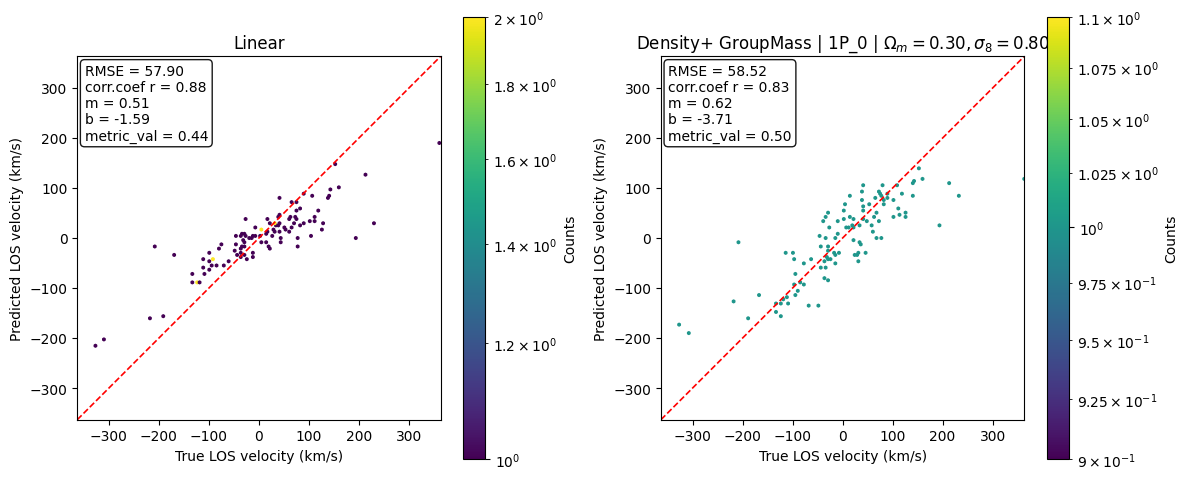

In [24]:
evaluate_model(
        model, te_loader, test_ds,
        y_mean, y_std,
        vlin_baseline, rho_vlin
    )